# Problem 3

In [91]:
# Problem 3 Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [160]:
# Problem 3(a)(i)
penguins = pd.read_csv("penguins.csv")
print(f"Shape: {penguins.shape}")
print(penguins.describe())

Shape: (344, 8)
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   344.000000  
mean   2008.029070  
std       0.818356  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  


In [93]:
# 3(a)(i) continued...
# how many penguins in each species?
print(penguins["species"].value_counts())

# how many penguins on each island?
print(penguins["island"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


In [94]:
# 3(a)(ii)

# report the number of missing values per column
missing_values = penguins.isnull().sum()
print("Missing values per column:")
print(missing_values)

# out of the 4 numerical features, drop rows with any missing values
numerical_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins_clean = penguins.dropna(subset=numerical_features) 

print(f"Shape after dropping rows with missing numerical features: {penguins_clean.shape}")
print("Number of penguins remaining: ", len(penguins_clean))

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Shape after dropping rows with missing numerical features: (342, 8)
Number of penguins remaining:  342


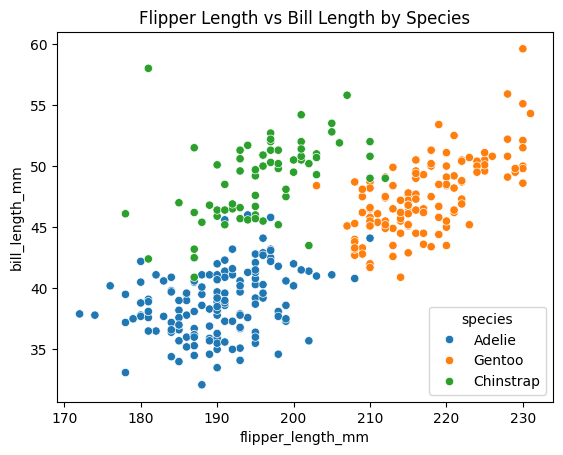

In [95]:
# 3(a)(iii)

#scatter plot of flipper_length_mm vs bill_length_mm, colored by species
sns.scatterplot(data=penguins_clean, x="flipper_length_mm", y="bill_length_mm", hue="species")
plt.title("Flipper Length vs Bill Length by Species")
plt.show()

 - Yes, I see three blobs by eye.
 - It looks like Adelie and Chinstrap are the most similar in this 2D projection, as the orange dots are slightly farther away from those two as they are to each other. 

In [96]:
# 3(b)(i)

# get the categorical columns
categorical_cols = penguins_clean.select_dtypes(include=["object"]).columns

# grab the species column and set it aside as ground truth
y = penguins_clean["species"]

# now drop the categorical columns and the year column to get the numerical data
penguins_numerical = penguins_clean.drop(columns=categorical_cols)
penguins_numerical = penguins_numerical.drop(columns=["year"])
print(f"Shape of numerical data: {penguins_numerical.shape}")
print(penguins_numerical.head())

Shape of numerical data: (342, 4)
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0


C:\Users\thebr\AppData\Local\Temp\ipykernel_584\738045633.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = penguins_clean.select_dtypes(include=["object"]).columns


In [97]:
# 3(b)(ii)
# See the below markdown cell.

 - We standardize because if we did not standardize, this exact scenario would happen where the feature with the larger raw values will dominate and seem to have a higher importance or influence on the decision, when in reality, that is only because of its magnitude.
 - Standardizing allows for actual meaningful relationships between different features with different magnitudes to be determined (i.e. how important a feature is).

In [98]:
# 3(b)(iii)

# standardize the four features to zero mean and unit variance using the training-data statistics
mean = penguins_numerical.mean()
std = penguins_numerical.std()
penguins_standardized = (penguins_numerical - mean) / std

# print the resulting means and standard deviations of each feature
print("Means after standardization:")
print(penguins_standardized.mean())

print("\nStandard deviations after standardization:")
print(penguins_standardized.std())

Means after standardization:
bill_length_mm       8.310441e-17
bill_depth_mm        4.155221e-16
flipper_length_mm   -8.310441e-16
body_mass_g          1.246566e-16
dtype: float64

Standard deviations after standardization:
bill_length_mm       1.0
bill_depth_mm        1.0
flipper_length_mm    1.0
body_mass_g          1.0
dtype: float64


In [99]:
# 3(c)(i)

def kmeans(X, k, max_iter=100, seed=0):
    np.random.seed(seed)
    n_samples, n_features = X.shape
    
    # pick k data points
    initial_indices = np.random.choice(n_samples, size=k, replace=False)
    centroids = X[initial_indices]
    
    for iteration in range(max_iter):
        # assign each data point to the nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # shape (n_samples, k)
        closest_centroids = np.argmin(distances, axis=1)  # shape (n_samples,)
        
        # calculate mean of assigned points to update centroids
        new_centroids = np.array([X[closest_centroids == i].mean(axis=0) for i in range(k)])
        
        # check convergence (centroids did not change)
        if np.all(centroids == new_centroids):
            print(f"Converged after {iteration} iterations.")
            break
        
        centroids = new_centroids
    
    # return the final centroids, final cluster labels, and the final inertia J
    inertia = np.sum([np.linalg.norm(X[closest_centroids == i] - centroids[i])**2 for i in range(k)])
    return centroids, closest_centroids, inertia

Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged after 3 iterations.
Converged 

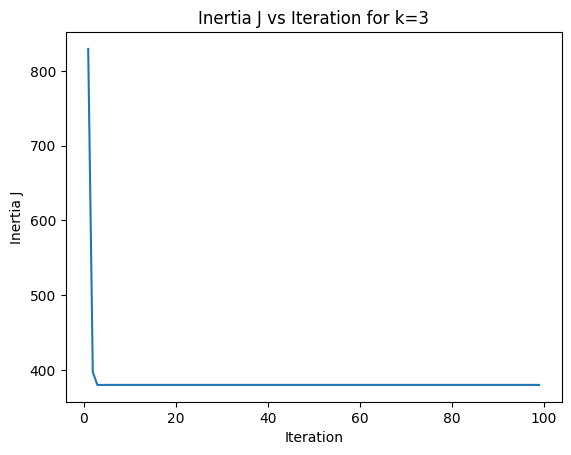

In [100]:
# 3(c)(ii)

# plot J as a function of iteration on a single example run with k=3
inertias = []
for iteration_count in range(1, 100):
    centroids, labels, inertia = kmeans(penguins_standardized.values, k=3, max_iter=iteration_count, seed=0)
    inertias.append(inertia)

plt.plot(range(1, 100), inertias)
plt.xlabel("Iteration")
plt.ylabel("Inertia J")
plt.title("Inertia J vs Iteration for k=3")
plt.show()

Visually, the monotone-decrease property is met here, as the inertia J decreases and then does not decrease after approximately 4 iterations.

In [101]:
# 3(d)(i)

# run the kmeans with k=3 on the four standardized features
centroids, labels, inertia = kmeans(penguins_standardized.values, k=3, max_iter=100, seed=0)
print("Final Inertia: ", inertia)

Converged after 3 iterations.
Final Inertia:  379.99647681865895


In [102]:
# 3(d)(ii)

# use pandas.crosstab to cross-tabulate the k=3 cluster labels against the true species column
crosstab = pd.crosstab(labels, penguins_clean["species"])
print(crosstab)

# assign each cluster to its majority-class species, then count how many penguins ended up in their majority cluster
cluster_to_species = crosstab.idxmax(axis=1)

# compare how many penguins were assigned to the cluster corresponding to their true species
predicted_species = cluster_to_species[labels].values

accuracy = (predicted_species == penguins_clean["species"].values).mean()
print(f"Clustering purity: {accuracy:.4f}")

species  Adelie  Chinstrap  Gentoo
row_0                             
0           144          5       0
1             7         63       0
2             0          0     123
Clustering purity: 0.9649


In [103]:
# 3(d)(iii)

# inverse-transform the centroids back to the original measurement scale by undoing the standardization
centroids_original_scale = centroids * std.values + mean.values

# display the centroids in a small table indexed by cluster
centroids_df = pd.DataFrame(centroids_original_scale, columns=penguins_numerical.columns)
centroids_df.index.name = "Cluster"
print(centroids_df)

         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
Cluster                                                               
0             38.642282      18.232886         189.463087  3654.865772
1             48.864286      18.660000         196.700000  3829.642857
2             47.504878      14.982114         217.186992  5076.016260


 - Cluster 0's centroid represents a short, deep bill, a short flipper, and a small body.
 - Cluster 1's centroid represents a long, deep bill with a medium-sized flipper and a small body.
 - Cluster 2's centroid represents a long, shallow bill with long flippers and a large body.

Text(0.5, 1.0, 'Flipper Length vs Bill Length by Cluster Label')

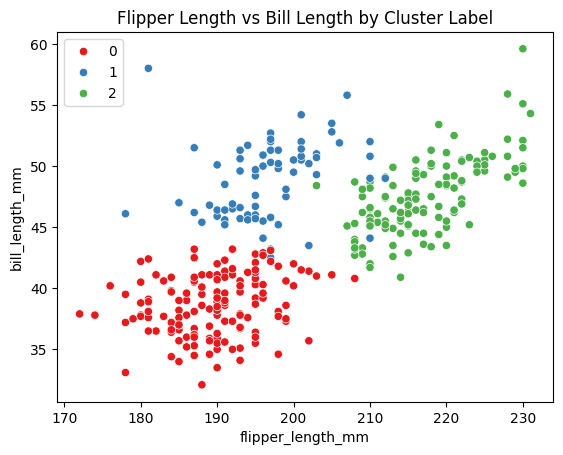

In [104]:
# 3(d)(iv)

# reproduce the scatter plot of flipper length vs bill length again, but now color points by cluster label
sns.scatterplot(data=penguins_clean, x="flipper_length_mm", y="bill_length_mm", hue=labels, palette="Set1")
plt.title("Flipper Length vs Bill Length by Cluster Label")

 - It looks very similar to the species-colored version.
 - It differs in the few overlapping points between the three classes. There are some outliers from each class that appear in different classes, and the model does not predict those few outliers correctly, but the rest of the points are grouped together correctly.

Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 1 iterations.
Converged after 4 iterations.
Converged after 7 iterations.
Converged after 2 iterations.
Converged after 5 iterations.
Converged after 6 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 7 iterations.
Converged after 3 iterations.
Converged after 15 iterations.
Converged after 6 iterations.
Converged after 10 iterations.
Converged after 7 iterations.
Converged after 9 iterations.
Converged after 7 iterations.
Converged after 5 iterations.
Converged after 5 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 9 iterations.
Converge

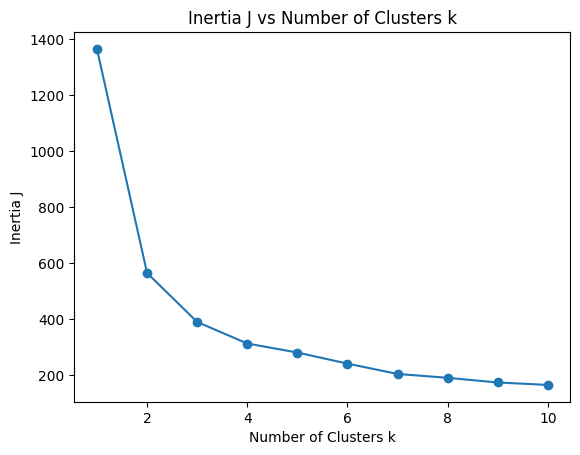

In [105]:
# 3(e)(i)

# run the k-means algorithm for k=1, 2, ... , 10
inertias_k = []
for k in range(1, 11):
    # average the final inertia over 10 random initializations (different seeds)
    total_inertia = 0
    for _ in range(10):
        centroids, labels, inertia = kmeans(penguins_standardized.values, k=k, max_iter=100, seed=_)
        total_inertia += inertia
    inertias_k.append(total_inertia / 10)

plt.plot(range(1, 11), inertias_k, marker='o')
plt.xlabel("Number of Clusters k")
plt.ylabel("Inertia J")
plt.title("Inertia J vs Number of Clusters k")
plt.show()

In [106]:
# 3(e)(ii)
# See the below markdown cell.

 - The elbow is at k = 4 clusters, as this is where the curve clearly starts bending and not changing enough to matter.
 - This is consistent because it is very similar to the number of species, which is 3. An argument can also be made for the bend actually being at 3 clusters, as this the slope of the curve goes down significantly here.

Converged after 4 iterations.
Converged after 7 iterations.
Converged after 2 iterations.
Converged after 5 iterations.
Converged after 6 iterations.
Converged after 4 iterations.
Converged after 2 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 7 iterations.
Converged after 3 iterations.
Converged after 15 iterations.
Converged after 6 iterations.
Converged after 10 iterations.
Converged after 7 iterations.
Converged after 9 iterations.
Converged after 7 iterations.
Converged after 5 iterations.
Converged after 5 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 9 iterations.
Converged after 8 iterations.
Converged after 4 iterations.
Converged after 8 iterations.
Converged after 7 iterations.
Converged after 8 iterations.
Converged after 6 iterations.
Converged after 3 iterations.
Converged after 8 iterations.
Converged after 6 iterations.
Converged after 18 iterations.
Converg

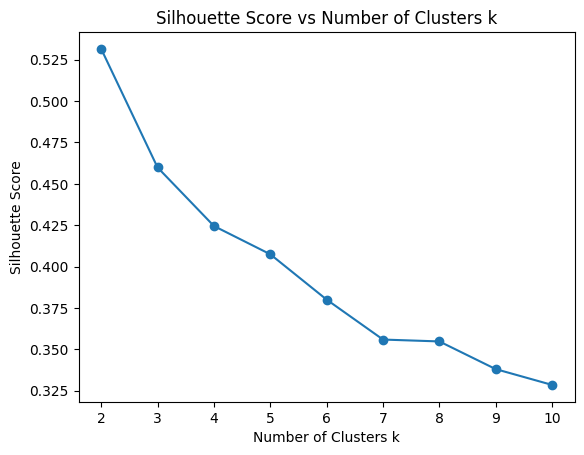

In [107]:
# 3(f)(i)

# run k-means once (best of 10 random inits), compute the silhouette score using
# sklearn.metrics.silhouette_score, and plot the silhouette score vs. k
silhouette_scores = []
for k in range(2, 11): 
    best_silhouette = -1
    for _ in range(10):
        centroids, labels, inertia = kmeans(penguins_standardized.values, k=k, max_iter=100, seed=_)
        score = silhouette_score(penguins_standardized.values, labels)
        # note that this was already imported from sklearn.metrics
        best_silhouette = max(best_silhouette, score)
    silhouette_scores.append(best_silhouette)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters k")
plt.show()

In [108]:
# 3(f)(ii)
# See the below markdown cell.

 - k=2 maximizes the silhouette score.
 - This does not agree with the elbow of k=3 from part (e), which had k=3.
 - They disagree, and I trust the elbow from part (e) more than the silhouette score plot because we know from the visual plots of the data points that there should actually be 3 clusters because we are trying to group 3 species. Therefore, k=3 clusters makes more sense than k=2, intuitively.

Converged after 8 iterations.
Converged after 5 iterations.
Converged after 7 iterations.
Converged after 9 iterations.
Converged after 6 iterations.
Converged after 5 iterations.
Converged after 6 iterations.
Converged after 6 iterations.
Converged after 7 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converged after 9 iterations.
Converged after 6 iterations.
Converged after 5 iterations.
Converged after 6 iterations.
Converged after 7 iterations.
Converged after 5 iterations.
Converged after 7 iterations.
Converged after 3 iterations.
Converged after 6 iterations.
Converged after 10 iterations.
Converged after 3 iterations.
Converged after 10 iterations.
Converged after 7 iterations.
Converged after 5 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converged after 8 iterations.
Converged after 7 iterations.
Converged after 6 iterations.
Converged after 9 iterations.
Converged after 4 iterations.
Converged after 6 iterations.
Converge

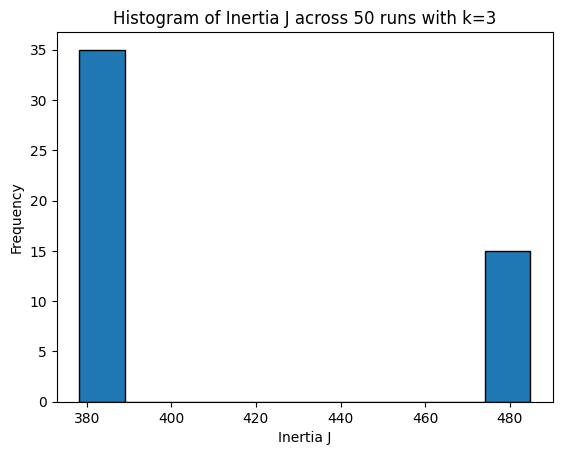

In [109]:
# 3(g)(i)

# run k=means with k=3 for 50 different random seeds
inertias_50 = []
seeds = np.random.choice(1000, size=50, replace=False)  # generate 50 unique random seeds
for seed in seeds:
    centroids, labels, inertia = kmeans(penguins_standardized.values, k=3, max_iter=100, seed=seed)
    inertias_50.append(inertia)

# plot a histogram of the inertia values obtained across the 50 runs
plt.hist(inertias_50, bins=10, edgecolor='black')
plt.xlabel("Inertia J")
plt.ylabel("Frequency")
plt.title("Histogram of Inertia J across 50 runs with k=3")
plt.show()

The spread of inertias goes from around 380 to around 480, with no inertia values in between those two buckets.

Converged after 6 iterations.
Converged after 7 iterations.


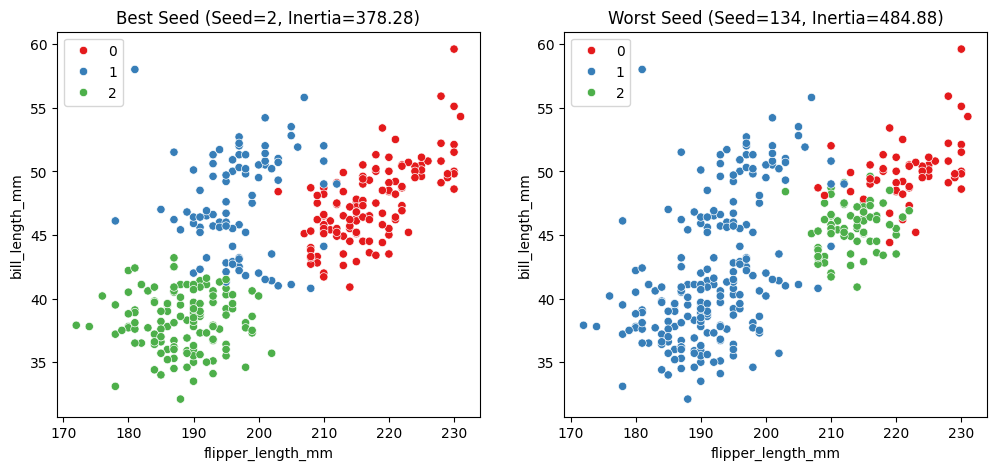

In [110]:
# 3(g)(ii)

# for two specific seeds (one giving the lowest inertia, one giving the highest)
# make side-by-side scatter plots of flipper length vs bill length colored by cluster label, one for each seed
best_seed = seeds[np.argmin(inertias_50)]
worst_seed = seeds[np.argmax(inertias_50)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed, title in zip(axes, [best_seed, worst_seed], ["Best Seed", "Worst Seed"]):
    centroids, labels, inertia = kmeans(penguins_standardized.values, k=3, max_iter=100, seed=seed)
    sns.scatterplot(data=penguins_clean, x="flipper_length_mm", y="bill_length_mm", hue=labels, palette="Set1", ax=ax)
    ax.set_title(f"{title} (Seed={seed}, Inertia={inertia:.2f})")

The two clusterings disagree radically, not just on a few points.
 - Specifically, the worst seed groups Class 1 and Class 2 penguins into the same class (Class 1) and Class 0 is split up into Class 0 + Class 1, which is almost completely incorrect classification.
 - The best seed gives the expected plot that looks visually the same as the actual plot of penguins by flipper and bill length.

In [111]:
# 3(h)
# See the below markdown cell.

I found three groups of penguins and I am very confident in that number because the elbow of the inertia vs. number of clusters plot is at k = 3 and the maximum silhouette value is at k = 2, which is very close to this value of k = 3. k = 2 was not chosen because of the prior knowledge that there are 3 clusters.
The unsupervised clustering recovered the recorded species labels with very high accuracy (clustering purity of about 0.96). Comparing this with the original plot of bill length vs. flipper length showed that the classes were separated in the same way as the original labels, which makes sense.
One limitation of this analysis is the fact that there are not enough morphological features to be able to make a better distinction between classes of penguins. It would be good to have one or two new features to distinctly separate two overlapping species in low-dimensional space.

# Problem 4

In [112]:
# Problem 4 Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap 
from sklearn.linear_model import LogisticRegression

In [161]:
# Problem 4(a)(i)
data = pd.read_csv("data.csv")
labels = pd.read_csv("labels.csv")

# drop the first column from data.csv
data = data.drop(columns=[data.columns[0]])

# print the data shape (801 by 20531)
print(f"Data shape: {data.shape}")

# report the count of samples in each tumor class
print(labels["Class"].value_counts())

Data shape: (801, 20531)
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


In [114]:
# 4(a)(ii)

# print summary statistics on a few random gene columns
np.random.seed(42)
random_cols = np.random.choice(data.columns, size=5, replace=False)

# convert these results into a table
summary_stats = data[random_cols].describe().transpose()
print("\nSummary Statistics Table:")   
print(summary_stats)


Summary Statistics Table:
            count       mean       std       min        25%        50%  \
gene_1272   801.0  11.063668  1.051581  5.064111  10.505047  11.172234   
gene_3222   801.0   6.614294  2.938234  0.000000   4.502872   6.300005   
gene_6423   801.0  10.556457  0.549155  8.978241  10.170013  10.500324   
gene_16755  801.0   0.278427  0.564358  0.000000   0.000000   0.000000   
gene_12457  801.0   0.010162  0.092842  0.000000   0.000000   0.000000   

                  75%        max  
gene_1272   11.677772  14.292135  
gene_3222    8.917253  14.245501  
gene_6423   10.899795  12.795739  
gene_16755   0.416083   3.828093  
gene_12457   0.000000   1.725305  


The range I see is approximately 0 to 15 for each gene.

In [115]:
# 4(a)(iii)

# standardize the gene columns to zero mean and unit variance
mean = data.mean()
std = data.std().replace(0, 1)
data_standardized = (data - mean) / std

We should standardize here because we do not want the raw numerical value of the features to play a role in determining how much influence they have on the model. For example, very high values like 200 (relative to low values like 1) are unacceptable because then the weights will be very imbalanced and it will not be easy to determine what features are important relative to other features.

In [116]:
# 4(b)(i)
def pca_svd(X, k):
    X_centered = X - np.mean(X, axis=0)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    
    X_pca = U[:, :k] @ np.diag(S[:k])
    return X_pca, Vt[:k, :], S # Return S here

In [117]:
# 4(b)(ii)
# calculate the variance
X_pca, components, S = pca_svd(data_standardized, k=2)

n = data_standardized.shape[0]
# eigenvalues (Variances) = (Singular Values^2) / (n - 1)
explained_variances = (S**2) / (n - 1)

print(f"Explained variance for component 0: {explained_variances[0]}")
print(f"Explained variance for component 1: {explained_variances[1]}")

Explained variance for component 0: 2135.7812928853186
Explained variance for component 1: 1773.9576675841247


In [118]:
# 4(c)(i)
def pca_eig(X, k):
    N, d = X.shape
    X_c = X - np.mean(X, axis=0)
    
    # compute the gram matrix G
    G = (1 / (N - 1)) * (X_c @ X_c.T)

    # eigendecompose G
    lambdas, U = np.linalg.eigh(G)

    # sort the eigenvalues in descending order 
    idx = np.argsort(lambdas)[::-1]
    lambdas = lambdas[idx]
    U = U[:, idx]

    # select only the top k eigenvalues
    lambdas_k = lambdas[:k]
    U_k = U[:, :k]

    # recover principal axes by this formula:
    # v_j = (X_c.T @ u_j) / sqrt((N-1) * lambda_j)
    # (d, N) @ (N, k) -> (d, k), then transpose to get (k, d)
    denom = np.sqrt((N - 1) * lambdas_k)
    components = (X_c.T @ U_k / denom).T

    # project the data onto these components
    projected = X_c @ components.T
    
    # return stuff
    explained_variance = lambdas_k
    return components, projected, explained_variance

In [119]:
# 4(c)(ii)
eig = pca_eig(data_standardized, k=2)

# print the explained variances for components 0 and 1
print(f"Explained variance for component 0: {eig[2][0]}")
print(f"Explained variance for component 1: {eig[2][1]}")

# print the principal axes (components) for both methods to verify they are the same
print("Principal axes from SVD method:")
print(components)
print("\nPrincipal axes from Eigen decomposition method:")
print(eig[0])

Explained variance for component 0: 2135.7812928853205
Explained variance for component 1: 1773.957667584125
Principal axes from SVD method:
[[ 0.00097941 -0.00235639 -0.00496579 ...  0.00233708  0.00195967
   0.00104891]
 [ 0.00230787 -0.00637287  0.00046648 ... -0.01493974 -0.00232062
   0.00100493]]

Principal axes from Eigen decomposition method:
     gene_0    gene_1    gene_2    gene_3    gene_4  gene_5    gene_6  \
0 -0.000979  0.002356  0.004966  0.008465  0.011697     0.0  0.005086   
1 -0.002308  0.006373 -0.000466  0.001566 -0.000524     0.0 -0.004196   

     gene_7    gene_8    gene_9  ...  gene_20521  gene_20522  gene_20523  \
0 -0.003076  0.000502  0.000535  ...   -0.012052   -0.001622   -0.002016   
1  0.001237 -0.000860  0.001127  ...    0.009373    0.015770    0.006791   

   gene_20524  gene_20525  gene_20526  gene_20527  gene_20528  gene_20529  \
0    0.002305   -0.012779   -0.000375   -0.004694   -0.002337   -0.001960   
1    0.007437    0.010350   -0.007708    0.0

Both checks confirm agreement.
 - The explained variances are the same, up to floating-point error.
 - The principal axes are the same up to a sign flip, as the numbers reported in the above cell match, up to sign flips.

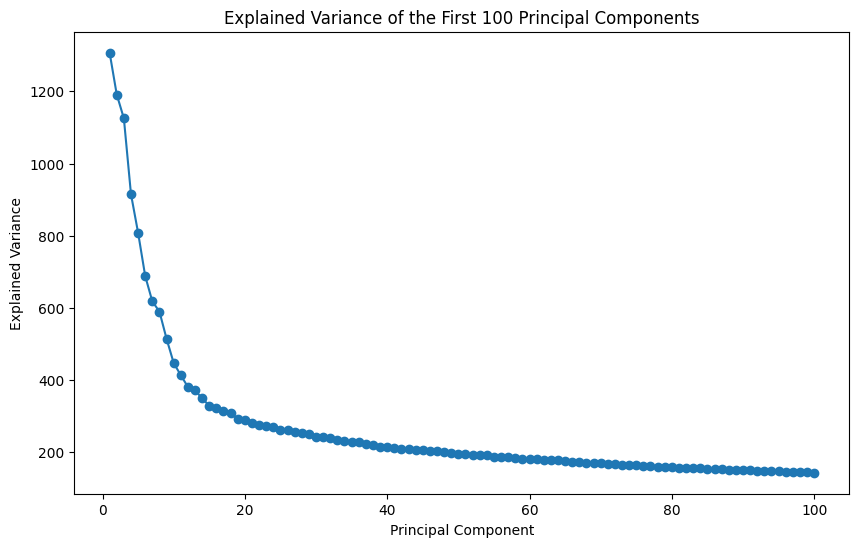

In [120]:
# 4(d)(i)

# run PCA with k = 100
X_pca_100, components_100, explained_variance_100 = pca_svd(data_standardized, k=100)

# plot the explained variance of each component
plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), explained_variance_100[:100], marker='o')
plt.ylabel('Explained Variance')
plt.xlabel('Principal Component')
plt.title('Explained Variance of the First 100 Principal Components')
plt.show()

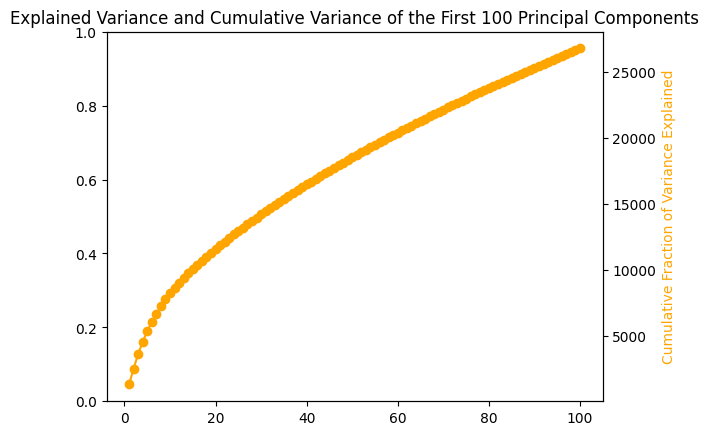

In [121]:
# on a separate axis, plot the cumulative fraction of variance explained
plt.twinx()
cumulative_variance = np.cumsum(explained_variance_100[:100])
np.sum(explained_variance_100)
plt.plot(range(1, 101), cumulative_variance, marker='o', color='orange')
plt.ylabel('Cumulative Fraction of Variance Explained', color='orange')
plt.xlabel('Principal Component')
plt.title('Explained Variance and Cumulative Variance of the First 100 Principal Components')
plt.show()

In [122]:
# 4(d)(ii)
# See the below markdown cell.

 - Approximately 70 components are needed to explain 80% of the variance (at least out of the first 100 components).
 - This is a very small amount compared to the original 20,531 genes, and indicates that we do not need most of the genes to explain most of the variance. 

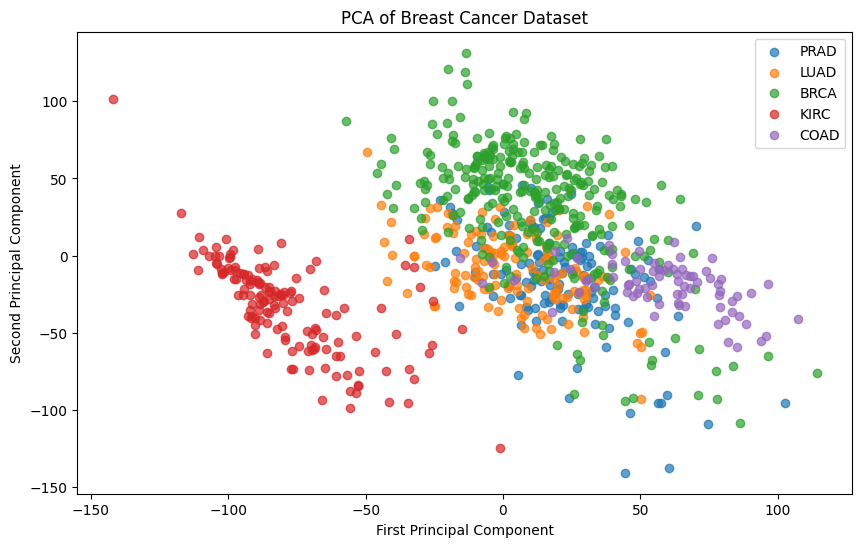

In [123]:
# 4(e)

# project all 801 samples to 2D using the PCA implementation
components, projected, explained_variance = pca_eig(data_standardized, k=2)

# make a scatter plot and color each point by its tumor type (5 colors, with a legend)
plt.figure(figsize=(10, 6))
for tumor_type in labels["Class"].unique():
    idx = labels["Class"] == tumor_type
    projected_array = projected.values  # or np.array(projected)
    plt.scatter(projected_array[idx, 0], projected_array[idx, 1], label=tumor_type, alpha=0.7)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA of Breast Cancer Dataset")
plt.legend()
plt.show()

 - Tumors of the same type do cluster together; the adenocarcinoma tumors and the one carcinoma tumor (which are similar, logically) are together in the giant cluster on the right side of the plot, while the clear cell tumor is very separated on the left side.
 - PCA succeeds in separating KIRC from the rest of the tumors in 2D, but will confuse the other four tumors because they are not linearly separable in 2 dimensions.

In [124]:
# 4(f)(i)

# take the first principal component (a vector of length 20,531)
first_pc = components.iloc[0].to_numpy()

# report the indices and values of the 10 genes with the largest absolute loadings
abs_loadings = np.abs(first_pc)
top_10_indices = np.argsort(abs_loadings)[-10:][::-1]
top_10_values = abs_loadings[top_10_indices]

print("Top 10 genes with largest absolute loadings:")
for i in range(10):
    print(f"Gene {top_10_indices[i]}: {top_10_values[i]:.4f}")

Top 10 genes with largest absolute loadings:
Gene 19862: 0.0190
Gene 17360: 0.0190
Gene 13489: 0.0190
Gene 15158: 0.0188
Gene 7031: 0.0187
Gene 7019: 0.0187
Gene 10788: 0.0186
Gene 13507: 0.0186
Gene 6543: 0.0186
Gene 2288: 0.0186


In [125]:
# 4(f)(ii)

# repeat for the second principal component
second_pc = components.iloc[1].to_numpy()
abs_loadings_2 = np.abs(second_pc)
top_10_indices_2 = np.argsort(abs_loadings_2)[-10:][::-1]
top_10_values_2 = abs_loadings_2[top_10_indices_2]

print("\nTop 10 genes with largest absolute loadings for the second principal component:")
for i in range(10):
    print(f"Gene {top_10_indices_2[i]}: {top_10_values_2[i]:.4f}")


Top 10 genes with largest absolute loadings for the second principal component:
Gene 3612: 0.0203
Gene 1222: 0.0199
Gene 14699: 0.0199
Gene 1010: 0.0198
Gene 19498: 0.0195
Gene 1113: 0.0194
Gene 3603: 0.0193
Gene 364: 0.0192
Gene 11153: 0.0192
Gene 19866: 0.0191


The top genes for PC1 and PC2 are different. 
 - This makes sense given that principal components should be orthogonal to each other, so they should not be similar.

c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


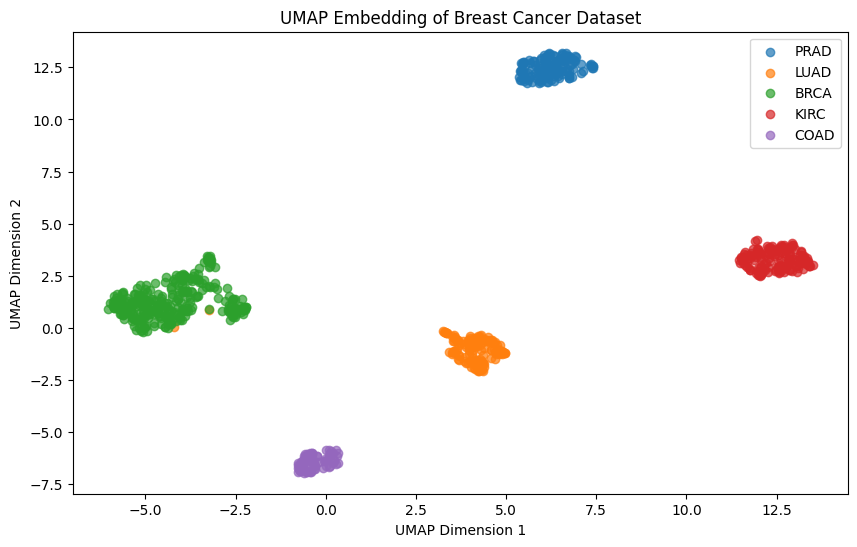

In [126]:
# 4(g)(i)
umap_embedding = umap.UMAP(n_components=2, random_state=42).fit_transform(data_standardized)

# make a 2D scatter plot of this UMAP embedding
plt.figure(figsize=(10, 6))
for tumor_type in labels["Class"].unique():
    idx = labels["Class"] == tumor_type
    plt.scatter(umap_embedding[idx, 0], umap_embedding[idx, 1], label=tumor_type, alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Embedding of Breast Cancer Dataset")
plt.legend()
plt.show()

In [127]:
# 4(g)(ii)
# See the below markdown cell.

 - The UMAP method gives more visually separable classes.
 - This is likely because it does not have to seek directions of maximum variance while PCA is required to. Because it can distort global distances, this is better for linear separation because local structure (i.e. similar tumors) will be preserved, while groups of tumors will be spread apart.

c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 

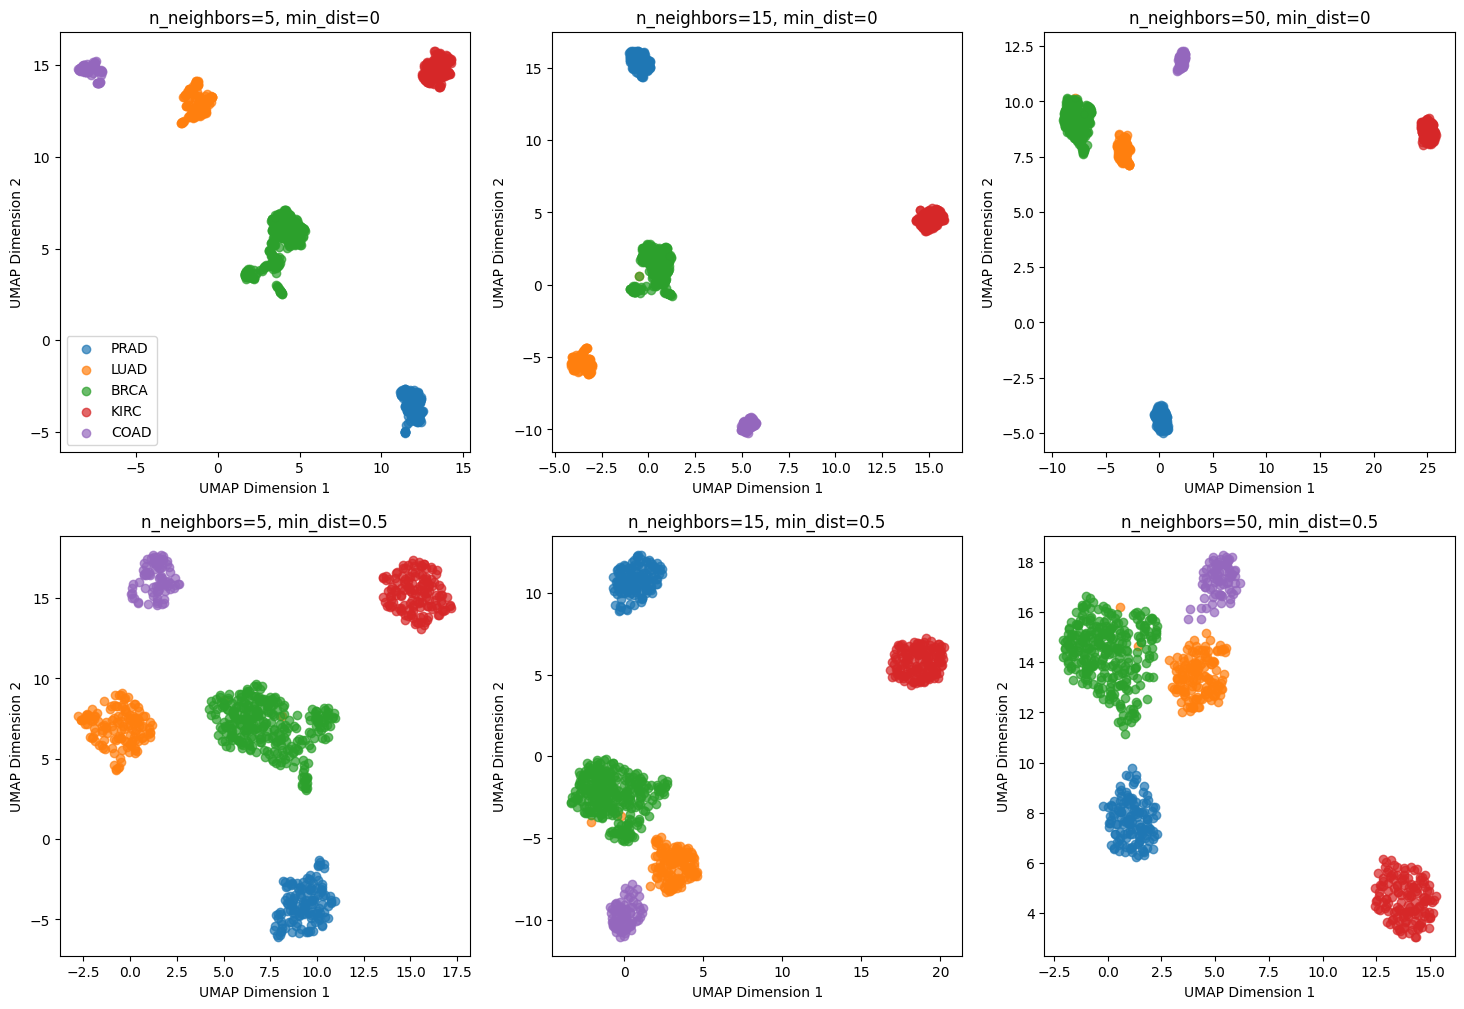

In [128]:
# 4(h)

# make a 2x3 grid of UMAP scatter plots for the six combinations of the following:
# (n_neighbors, min_dist) = (5, 0), (5, 0.5), (15, 0), (15, 0.5), (50, 0), (50, 0.5)
n_neighbors_values = [5, 15, 50]
min_dist_values = [0, 0.5]
plt.figure(figsize=(18, 12))
plot_num = 1
for min_dist in min_dist_values:
    for n_neighbors in n_neighbors_values:
        umap_embedding = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42).fit_transform(data_standardized)
        plt.subplot(2, 3, plot_num)
        for tumor_type in labels["Class"].unique():
            idx = labels["Class"] == tumor_type
            plt.scatter(umap_embedding[idx, 0], umap_embedding[idx, 1], label=tumor_type, alpha=0.7)
        plt.xlabel("UMAP Dimension 1")
        plt.ylabel("UMAP Dimension 2")
        plt.title(f"n_neighbors={n_neighbors}, min_dist={min_dist}")
        if plot_num == 1:
            plt.legend()
        plot_num += 1
plt.show()

How the embedding changes as the parameters are swept:
 - For higher n_neighbors, the clusters have more points, which results in them being more dense for a lower min_dist value but the same n_neighbors value.
 - For higher min_dist, the cluster is larger, visually, in size, as the points are spread farther apart.


I would ship the n_neighbors = 5, min_dist = 0 plot to the bioinformatics lab, as this has the highest amount of separation between the tumor classes and will be the easiest to separate later.


In [129]:
# 4(i)(i)

# split the 801 samples into 80% train, 20% test
np.random.seed(42)
num_samples = data_standardized.shape[0]
indices = np.random.permutation(num_samples)
train_size = int(0.8 * num_samples)
train_indices = indices[:train_size]
test_indices = indices[train_size:]
X_train = data_standardized.iloc[train_indices]
y_train = labels.iloc[train_indices]["Class"]
X_test = data_standardized.iloc[test_indices]
y_test = labels.iloc[test_indices]["Class"]

In [130]:
# 4(i)(ii)

# train three logistic regression classifiers (LogisticRegression(max_iter=2000))
# one on the full 20531 gene vector
# one on the 2D PCA embedding from part (e)
# one on the 2D UMAP embedding from part (g)

# Logistic regression on the full gene vector
logreg_full = LogisticRegression(max_iter=2000, random_state=42)
logreg_full.fit(X_train, y_train)

# Logistic regression on the 2D PCA embedding
logreg_pca = LogisticRegression(max_iter=2000, random_state=42)
logreg_pca.fit(projected.iloc[train_indices], y_train)

# Logistic regression on the 2D UMAP embedding 
umap_embedding_full = umap.UMAP(n_components=2, random_state=42).fit_transform(data_standardized)
logreg_umap = LogisticRegression(max_iter=2000, random_state=42)
logreg_umap.fit(umap_embedding_full[train_indices], y_train)

c:\Users\thebr\intro-ml\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [131]:
# 4(i)(iii)

# report test accuracy for each logistic regression model
accuracy_full = logreg_full.score(X_test, y_test)
accuracy_pca = logreg_pca.score(projected.iloc[test_indices], y_test)
accuracy_umap = logreg_umap.score(umap_embedding_full[test_indices], y_test)
print(f"Test accuracy for logistic regression on full gene vector: {accuracy_full:.4f}")
print(f"Test accuracy for logistic regression on 2D PCA embedding: {accuracy_pca:.4f}")
print(f"Test accuracy for logistic regression on 2D UMAP embedding: {accuracy_umap:.4f}")

Test accuracy for logistic regression on full gene vector: 0.9752
Test accuracy for logistic regression on 2D PCA embedding: 0.6832
Test accuracy for logistic regression on 2D UMAP embedding: 1.0000


 - The 2D UMAP embedding comes close (actually is better relative) to the full gene vector, but the PCA embedding does not come close to the full-feature baseline.
 - The 2D UMAP embedding is much closer to the full-feature baseline, and actually tops it by having 100% accuracy (likely because the islands were very well-separated in the 2D plot of UMAP embedding).
 - PCA with k=10 would do better than the current PCA because higher dimensionality would allow for easier linear separation, but it would likely not beat the 2D UMAP regression because it would likely get very close to, but not hit, 100% accuracy.

In [132]:
# 4(j)

# single table summarizing the method, dimensions, and downstream test accuracy as columns
# this should include the PCA method, the full-feature baseline, and UMAP
results = pd.DataFrame({
    "Method": ["Full Gene Vector", "PCA", "UMAP"],
    "Dimensions": [20531, 2, 2],
    "Test Accuracy": [accuracy_full, accuracy_pca, accuracy_umap]
})
print(results)

             Method  Dimensions  Test Accuracy
0  Full Gene Vector       20531       0.975155
1               PCA           2       0.683230
2              UMAP           2       1.000000


 - I would recommend using PCA with a higher k-value because this would have a high test accuracy and, unlike the UMAP approach (which has a high test accuracy), is more interpretable. This means that the actual vectors being used contain information about exactly what genes are influencing the classification rather than being a set of vectors designed solely to optimize the distances between classes.
 - I would use it when there are overlapping clusters in the 2D space that need to be separated, but I would not use it when the clusters in 2D space are already separated; we would only require PCA to do this because they are already visually linearly separated.

# Problem 5

In [133]:
# Problem 5 Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [162]:
# Problem 5(a)(i)
bank = pd.read_csv("bank-full.csv", sep=";")

# print shape, dtypes, and the head
print(f"Shape: {bank.shape}")
print(bank.dtypes)

Shape: (45211, 17)
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [135]:
print("First 5 rows:")
print(bank.head())

First 5 rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [136]:
# how many numerical and how many categorical features?
num_numerical = bank.select_dtypes(include=[np.number]).shape[1]
num_categorical = bank.select_dtypes(include=[object]).shape[1]
print(f"Numerical features: {num_numerical}")
print(f"Categorical features: {num_categorical}")

Numerical features: 7
Categorical features: 10


C:\Users\thebr\AppData\Local\Temp\ipykernel_584\879882629.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_categorical = bank.select_dtypes(include=[object]).shape[1]


In [137]:
# 5(a)(ii)
# what fraction of clients have y == 'yes'?
print(f"Fraction of clients with y == 'yes': {bank['y'].value_counts(normalize=True)['yes']:.4f}")

Fraction of clients with y == 'yes': 0.1170


In [138]:
# 5(a)(iii)
# drop 'duration' from the dataset
bank = bank.drop(columns=["duration"])

This is not a balanced classification problem because there is a large imbalance in the clients that have 'yes' and 'no'.
The trivial 'always predict no' classifier would achieve an 88.3% accuracy, which is already relatively high.

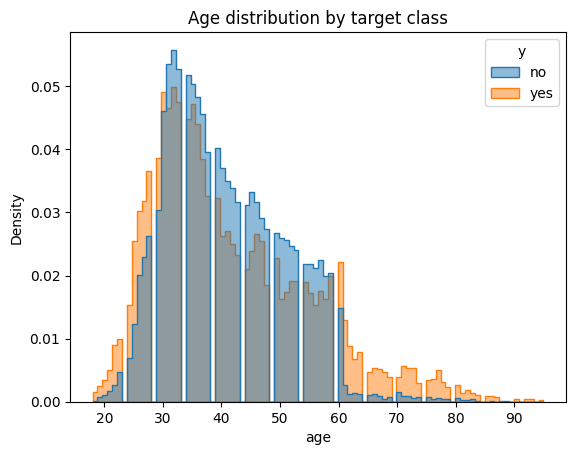

In [139]:
# 5(a)(iv)
# for age and balance, plot histograms split by the target y (overlaid with transparency)
sns.histplot(data=bank, x="age", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Age distribution by target class")
plt.show()

Here, we see the age distributions are relatively similar, but those that said "no" tend to be younger and in their 30s to 60s. Many of those that say "yes" are also generally in the 30s to 60s range, but there are more people in their 60s to 90s that said "yes." 

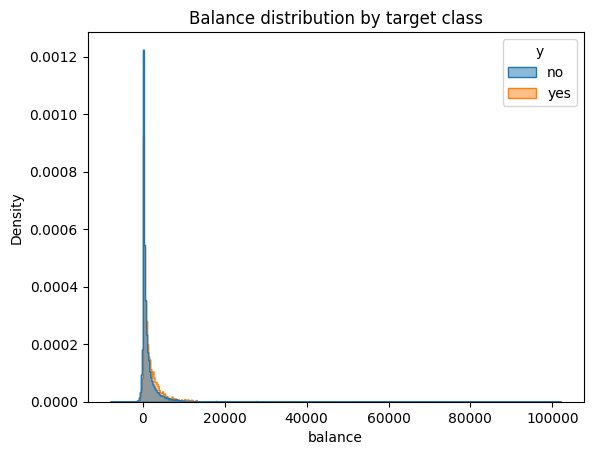

In [140]:
sns.histplot(data=bank, x="balance", hue="y", element="step", stat="density", common_norm=False, alpha=0.5)
plt.title("Balance distribution by target class")
plt.show()

Here, we see that for both "yes" and "no", the balance is highly concentrated at and near 0, with very few people at 20000 or higher, but still some sitting there. 

C:\Users\thebr\AppData\Local\Temp\ipykernel_584\2716277010.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)


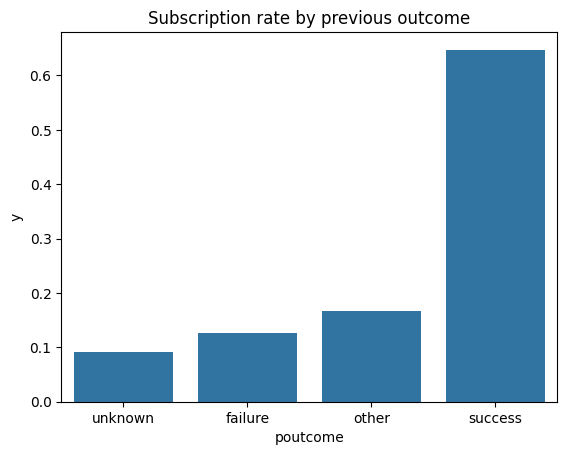

In [141]:
# do the same for "poutcome" using a bar chart of subscription rate per category
sns.barplot(data=bank, x="poutcome", y=bank["y"].map({"yes": 1, "no": 0}), ci=None)
plt.title("Subscription rate by previous outcome")
plt.show()

Here, we see that if the previous outcome was a "success", the subscription rate was very high, and if not a success, then the subscription rate was relatively low (at or below 0.2).

In [142]:
# 5(b)(i)

# encode the target (yes = 1, no = 0)
bank["y"] = bank["y"].map({"yes": 1, "no": 0})

# split into 60% train, 20% validation, 20% test
np.random.seed(42)
shuffled_indices = np.random.permutation(len(bank))
train_end = int(0.6 * len(bank))
val_end = int(0.8 * len(bank))

train_indices = shuffled_indices[:train_end]
val_indices = shuffled_indices[train_end:val_end]
test_indices = shuffled_indices[val_end:]

train_data = bank.iloc[train_indices]
val_data = bank.iloc[val_indices]
test_data = bank.iloc[test_indices]

# verify that the class balance is preserved across splits
print("Train class balance:")
print(train_data["y"].value_counts(normalize=True))
print("Validation class balance:")
print(val_data["y"].value_counts(normalize=True))
print("Test class balance:")
print(test_data["y"].value_counts(normalize=True))

Train class balance:
y
0    0.881811
1    0.118189
Name: proportion, dtype: float64
Validation class balance:
y
0    0.887193
1    0.112807
Name: proportion, dtype: float64
Test class balance:
y
0    0.882451
1    0.117549
Name: proportion, dtype: float64


The class balance is preserved across the splits.

In [146]:
# 5(b)(ii)

# One-hot encode all categorical features BEFORE splitting
categorical_cols = bank.select_dtypes(include=["object"]).columns
bank_encoded = pd.get_dummies(bank, columns=categorical_cols, drop_first=True)

# Then split
train_data_encoded = bank_encoded.iloc[train_indices]
val_data_encoded = bank_encoded.iloc[val_indices]
test_data_encoded = bank_encoded.iloc[test_indices]

print("Number of features after encoding: ", train_data_encoded.shape[1])

Number of features after encoding:  42


C:\Users\thebr\AppData\Local\Temp\ipykernel_584\918285832.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = bank.select_dtypes(include=["object"]).columns


In [147]:
# 5(c)(i)

# fit DecisionTreeClassifier on training data
X_train = train_data_encoded.drop(columns=["y"])
y_train = train_data_encoded["y"]
dt_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_clf.fit(X_train, y_train)

# report training and validation accuracy
X_val = val_data_encoded.drop(columns=["y"])
y_val = val_data_encoded["y"]
y_train_pred = dt_clf.predict(X_train)
y_val_pred = dt_clf.predict(X_val)
train_acc = metrics.accuracy_score(y_train, y_train_pred)
val_acc = metrics.accuracy_score(y_val, y_val_pred)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Training Accuracy: 0.8941
Validation Accuracy: 0.8934


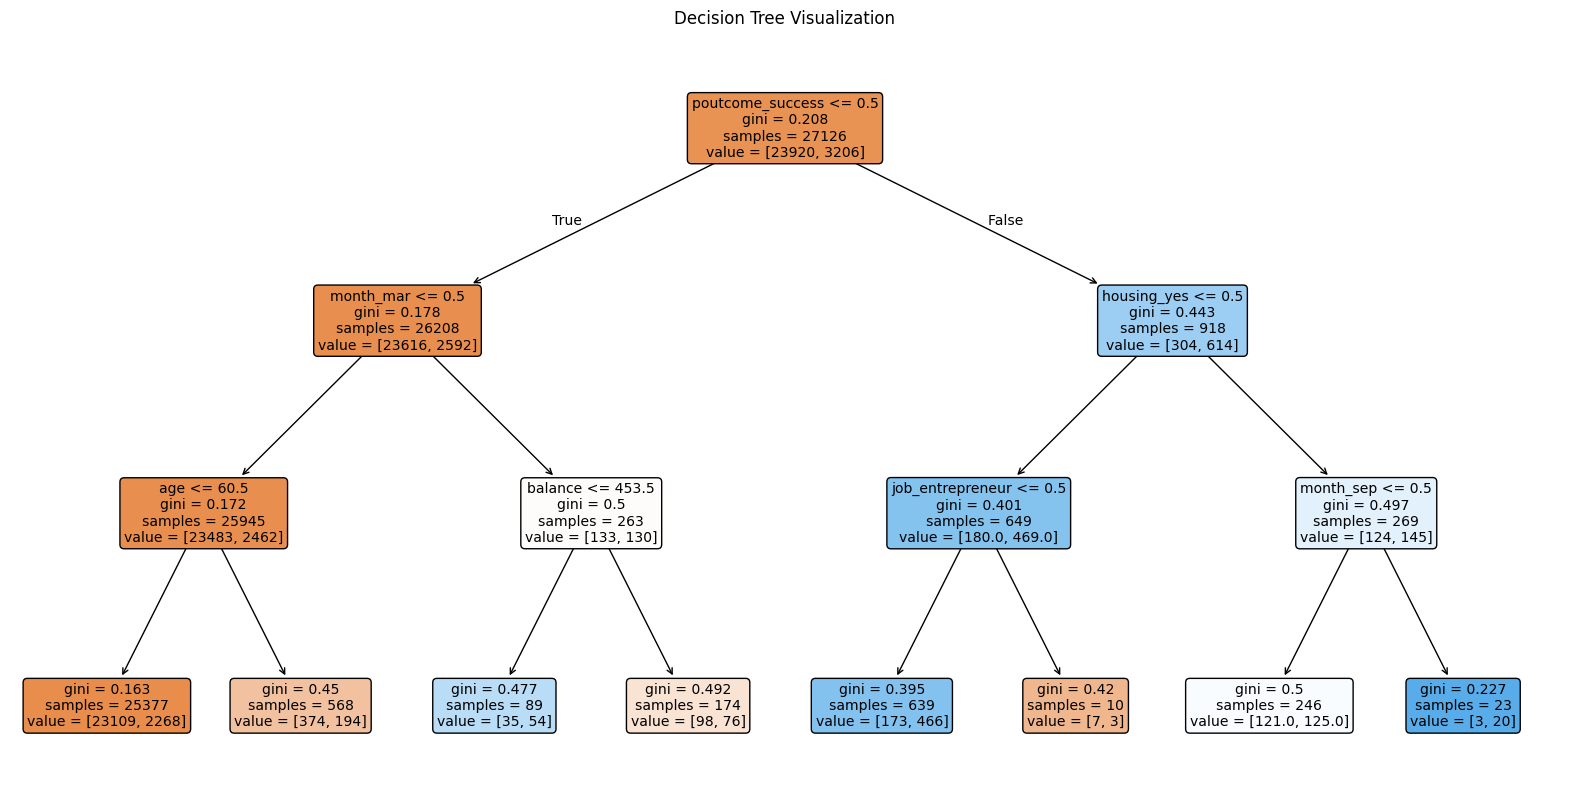

In [148]:
# 5(c)(ii)

# visualize the tree using sklearn.tree.plot_tree with feature_names so the splits are human-readable
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

In [149]:
# 5(d)(i)

# sweep max_depth within 1, 2, 3, 5, 7, 10, 15, 20, None (where None means unlimited)
# grow until every leaf is pure or below min_samples_split for None
# for each depth, report training and validation accuracy
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
results = []
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)
    train_acc = metrics.accuracy_score(y_train, y_train_pred)
    val_acc = metrics.accuracy_score(y_val, y_val_pred)
    results.append((depth, train_acc, val_acc))
    print(f"Max Depth: {depth}, Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")

Max Depth: 1, Training Accuracy: 0.8932, Validation Accuracy: 0.8945
Max Depth: 2, Training Accuracy: 0.8932, Validation Accuracy: 0.8945
Max Depth: 3, Training Accuracy: 0.8941, Validation Accuracy: 0.8934
Max Depth: 5, Training Accuracy: 0.8951, Validation Accuracy: 0.8943
Max Depth: 7, Training Accuracy: 0.8987, Validation Accuracy: 0.8931
Max Depth: 10, Training Accuracy: 0.9063, Validation Accuracy: 0.8924
Max Depth: 15, Training Accuracy: 0.9247, Validation Accuracy: 0.8871
Max Depth: 20, Training Accuracy: 0.9466, Validation Accuracy: 0.8769
Max Depth: None, Training Accuracy: 1.0000, Validation Accuracy: 0.8322


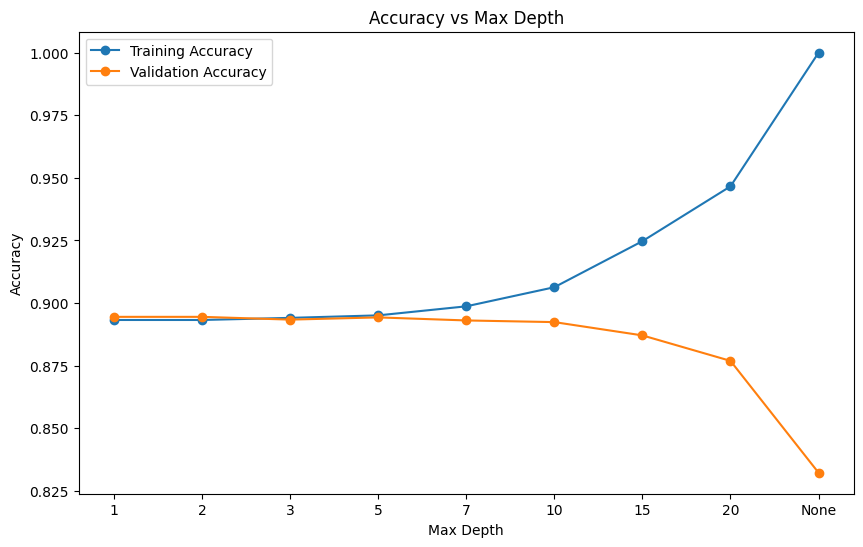

In [150]:
# 5(d)(ii)

# plot training and validation accuracy on the axes as a function of depth
depths_plot = [str(d) for d in depths]
train_accs = [r[1] for r in results]
val_accs = [r[2] for r in results]
plt.figure(figsize=(10, 6))
plt.plot(depths_plot, train_accs, marker='o', label='Training Accuracy')
plt.plot(depths_plot, val_accs, marker='o', label='Validation Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Max Depth")
plt.legend()
plt.show()

 - The validation accuracy peaks at Depth 5 (will not choose Depth 1 or 2 because later on, this does not produce good results).
 - After the peak, training accuracy keeps improving while validation degrades, and this is due to overfitting.
 - There is not much error from bias (simple assumptions) at a low depth, but there is a lot of error from variance (overfitting) as the max depth of the decision tree gets larger. This is similar to what we saw with the previously-fitted models where too complex of a model causes the model to memorize the training data and subsequently perform worse on the validation set.

In [151]:
# 5(e)(ii)

# for each max_depth from part d, perform 5-fold cross-validation on the training set
# this can be done with sklearn.model_selection.KFold or cross_val_score
from sklearn.model_selection import cross_val_score
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(f"Max Depth: {depth}, Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Max Depth: 1, Cross-Validation Accuracy: 0.8932 ± 0.0030
Max Depth: 2, Cross-Validation Accuracy: 0.8929 ± 0.0030
Max Depth: 3, Cross-Validation Accuracy: 0.8918 ± 0.0016
Max Depth: 5, Cross-Validation Accuracy: 0.8930 ± 0.0023
Max Depth: 7, Cross-Validation Accuracy: 0.8913 ± 0.0008
Max Depth: 10, Cross-Validation Accuracy: 0.8888 ± 0.0033
Max Depth: 15, Cross-Validation Accuracy: 0.8811 ± 0.0027
Max Depth: 20, Cross-Validation Accuracy: 0.8682 ± 0.0056
Max Depth: None, Cross-Validation Accuracy: 0.8256 ± 0.0043


In [152]:
# 5(e)(ii)

# refit depth 5 on the full training set
best_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
best_clf.fit(X_train, y_train)

# report test accuracy
X_test = test_data_encoded.drop(columns=["y"])
y_test = test_data_encoded["y"]
y_test_pred = best_clf.predict(X_test)
test_acc = metrics.accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8900


Yes, this matches what I would have picked from a single split in part (d).

Text(0.5, 1.0, 'Validation Accuracy vs Min Samples Leaf')

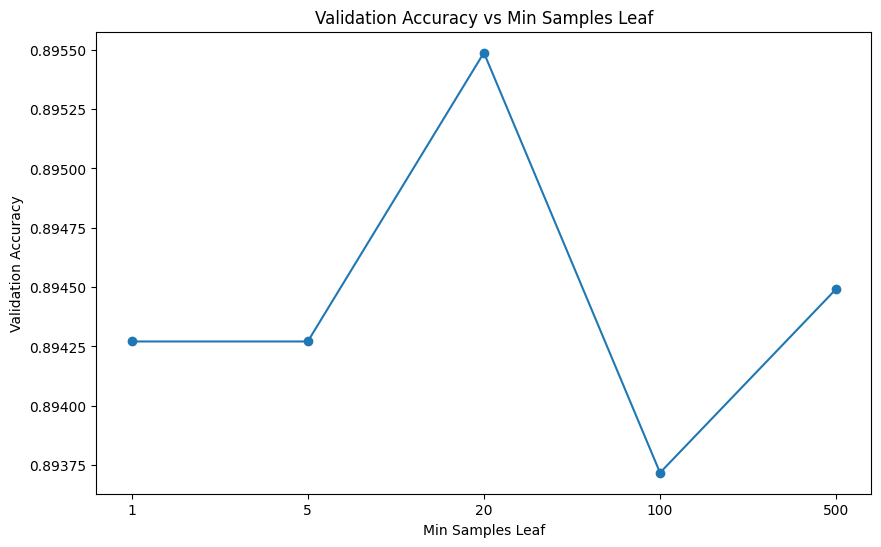

In [153]:
# 5(f)

# sweep min_samples_leaf from 1, 5, 20, 100, 500 at the best depth from part e
best_depth = 5
leaf_sizes = [1, 5, 20, 100, 500]
validation_results = []
for leaf_size in leaf_sizes:
    clf = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=leaf_size, random_state=42)
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    val_acc = metrics.accuracy_score(y_val, y_val_pred)
    validation_results.append((leaf_size, val_acc))

# plot validation accuracy vs min_samples_leaf
leaf_sizes_plot = [str(ls) for ls in leaf_sizes]
val_accs_leaf = [r[1] for r in validation_results]
plt.figure(figsize=(10, 6))
plt.plot(leaf_sizes_plot, val_accs_leaf, marker='o')
plt.xlabel("Min Samples Leaf")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Min Samples Leaf")

In [154]:
# report combined-test accuracy at the combination of 5 depth and 20 samples per leaf
final_clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
final_clf.fit(X_test, y_test)
final_test_acc = metrics.accuracy_score(y_test, final_clf.predict(X_test))
print(f"Final Test Accuracy (Depth=5, Min Samples Leaf=20): \n{final_test_acc:.4f}")

Final Test Accuracy (Depth=5, Min Samples Leaf=20): 
0.8964


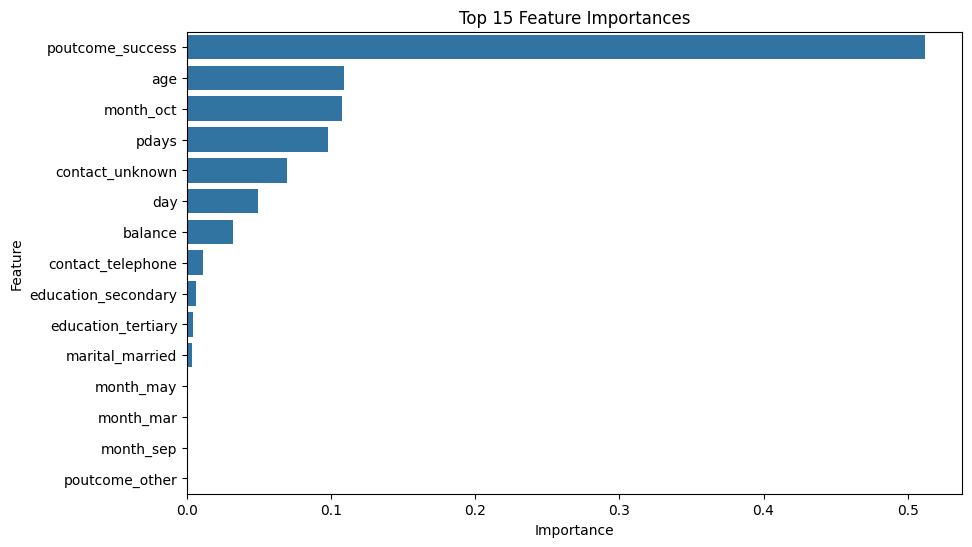

In [155]:
# 5(g)(i)

# extract tree.feature_importances_ 
# and plot the top 15 features by importance
feature_importances = final_clf.feature_importances_
top_15_indices = feature_importances.argsort()[::-1][:15]
top_15_features = X_train.columns[top_15_indices]
top_15_importances = feature_importances[top_15_indices]
plt.figure(figsize=(10, 6))
sns.barplot(x=top_15_importances, y=top_15_features)
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [156]:
# 5(g)(ii)
# See the below markdown cell.

 - The features that dominate are poutcome_success, age, month_oct, pdays, and contact_unknown. 
 - These match the patterns we saw in the EDA in part (a)(iv) because the tree did pick up on poutcome, contact, month, and age as four of the five most influential features.

In [157]:
# 5(h)

# make sure to standardize the numerical features first using their mean and std
X_train_mean = X_train.mean()
X_train_std = X_train.std()
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_val_scaled = (X_val - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

# train a logistic regression baseline on the same one-hot-encoded features
logreg_clf = LogisticRegression(max_iter=1000, random_state=42)
logreg_clf.fit(X_train_scaled, y_train)

# report test accuracy
y_test_pred_logreg = logreg_clf.predict(X_test_scaled)
logreg_test_acc = metrics.accuracy_score(y_test, y_test_pred_logreg)

print("Logistic Regression Test Accuracy: {:.4f}".format(logreg_test_acc))
print("Decision Tree Test Accuracy: {:.4f}".format(test_acc))

Logistic Regression Test Accuracy: 0.8897
Decision Tree Test Accuracy: 0.8900


 - The decision tree is faster to train.
 - The decision tree is easier to explain to a non-specialist, as it lays out "why" classifications are being made in terms of the features themselves.
 - The decision tree would likely handle a new categorical level more gracefully, as we can simply add another layer to the decision tree to handle this (if it is influential).

In [158]:
# 5(i)

# for the best tree, compute precision and recall on the test set
y_test_pred_tree = best_clf.predict(X_test)
precision = metrics.precision_score(y_test, y_test_pred_tree)
recall = metrics.recall_score(y_test, y_test_pred_tree)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.6133
Recall: 0.1731


 - The bank should care much more about the False Negatives, where the model predicted that the person "will not subscribe" but he/she would have actually said yes. This is because the cost of wasting one phone call on a False Positive does not matter as much as the cost of a lost paying customer.
 - I would tune the prediction threshold down to better serve the bank so that the number of False Negatives is minimized. This way, we get more False Positives, but we minimize the number of subscriptions lost.

In [159]:
# 5(j) 
# See the below markdown cell.

 - One thing we can try next is weighting the "Yes" labels more than the "No" labels so that deeper patterns are actually learned. This would force the Decision Tree to learn the patterns of subscribers rather than just guessing "No" for high accuracy.
 - Before deploying the model in production, I would investigate the time at which the data was collected, as it is logical that the decision of whether a person should subscribe to a bank is highly dependent on the economy and political environment.